In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd


In [2]:
data = pd.read_csv('data/DOHMH_New_York_City_Restaurant_Inspection_Results_20260820.csv',low_memory=False)

In [3]:
data.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50187072,JAZKAYA,Queens,37-11,30th Ave,11103.0,7186068686,NaN,01/01/1900,NaN,...,NaN,"40,76455981569","-73,91640395133",401.0,22.0,6502.0,4010730.0,4.006610e+09,QN70,POINT (-73.916403951333 40.764559815688)
1,50167097,CIELO NYC CORP,Queens,88-19,31 AVENUE,11369.0,9178537109,NaN,01/01/1900,NaN,...,NaN,"40,75987780914","-73,87991201121",403.0,25.0,33900.0,4624910.0,4.013860e+09,QN28,POINT (-73.879912011209 40.759877809136)
2,50187999,FRESH TACO,Queens,1701,PUTNAM AVENUE,11385.0,7188216563,NaN,01/01/1900,NaN,...,NaN,"40,70053320849","-73,90645489798",405.0,34.0,55100.0,4082690.0,4.034600e+09,QN20,POINT (-73.906454897979 40.700533208494)
3,50179663,TAXI CAFE,Queens,BLDG 187,CENTRAL TAXI HOLD LOT,11430.0,8455855146,NaN,01/01/1900,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,50171444,CHICKEN/FRIES CONCESSION,Manhattan,4,PENN PLAZA,10121.0,2124656000,NaN,01/01/1900,NaN,...,NaN,"40,75065483663","-73,99194423908",105.0,3.0,10100.0,1082908.0,1.007810e+09,MN17,POINT (-73.991944239076 40.750654836632)


In [4]:
# COLUMNA A ANALIZAR GRADE, TIPO: PROBLEMA DE CLASIFICACION

# MODELO: ROC-AUC (0.82,0.86)
# F1-SCORE
# Incremento de la penalizacion
# XGBoost
# K-Fold Cross Validator

#### FASE 1:

In [5]:
data.columns

Index(['CAMIS', 'DBA', 'BORO', 'BUILDING', 'STREET', 'ZIPCODE', 'PHONE',
       'CUISINE DESCRIPTION', 'INSPECTION DATE', 'ACTION', 'VIOLATION CODE',
       'VIOLATION DESCRIPTION', 'CRITICAL FLAG', 'SCORE', 'GRADE',
       'GRADE DATE', 'RECORD DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude',
       'Community Board', 'Council District', 'Census Tract', 'BIN', 'BBL',
       'NTA', 'Location'],
      dtype='object')

In [6]:
data.shape

(295473, 27)

In [7]:
data.dtypes

CAMIS                      int64
DBA                       object
BORO                      object
BUILDING                  object
STREET                    object
ZIPCODE                  float64
PHONE                     object
CUISINE DESCRIPTION       object
INSPECTION DATE           object
ACTION                    object
VIOLATION CODE            object
VIOLATION DESCRIPTION     object
CRITICAL FLAG             object
SCORE                    float64
GRADE                     object
GRADE DATE                object
RECORD DATE               object
INSPECTION TYPE           object
Latitude                  object
Longitude                 object
Community Board          float64
Council District         float64
Census Tract             float64
BIN                      float64
BBL                      float64
NTA                       object
Location                  object
dtype: object

#### FASE 2:

In [23]:
print(data.isna().sum())

CAMIS                         0
DBA                           2
BORO                          0
BUILDING                   1006
STREET                       35
ZIPCODE                    3100
PHONE                        97
CUISINE DESCRIPTION        3754
ACTION                     3674
VIOLATION CODE             6391
VIOLATION DESCRIPTION      6391
CRITICAL FLAG                 0
SCORE                     17179
GRADE                         0
INSPECTION TYPE            3674
Latitude                   1711
Longitude                  1711
Community Board            4767
Council District           4793
Census Tract               4793
BIN                        5992
BBL                        1711
NTA                        4767
Location                   4767
Inspection_year               0
Inspection_month              0
Grade_year               160593
Grade_month              160593
Record_year                   0
Record_month                  0
GRADE_es_nulo                 0
SCORE_es

In [9]:
# Tratado de los nulos de la columna GRADE

data['GRADE'].value_counts(dropna=False)

data['GRADE'] = data['GRADE'].fillna('unclassified')

data['GRADE'].value_counts(dropna=False)

GRADE
unclassified    150352
A                98025
B                18080
C                13234
N                10251
Z                 4778
P                  753
Name: count, dtype: int64

Falsos numéricos: 
1. Columnas como ZIPCODE, BIN, BBL, Community Board y Council District aparecen como float64.
2. Aunque son números, en realidad son categorías o identificadores geográficos.
3. El código postal 10002 no "vale más" numéricamente que el 10001. Debes convertirlos a tipo object o string para que el modelo no asuma una relación matemática falsa.

In [10]:
# ZIPCODE

data['ZIPCODE'] = data['ZIPCODE'].astype(object)

# BIN

data['BIN'] = data['BIN'].astype(object)

# COMMUNITY BOARD

data['Community Board'] = data['Community Board'].astype(object)

# COUNCIL DISTRICT

data['Council District'] = data['Council District'].astype(object)

# BBL

data['BBL'] = data['BBL'].astype(object)

Fechas ocultas: 
1. INSPECTION DATE, GRADE DATE y RECORD DATE están como object (texto). Conviene pasarlos a formato datetime

In [11]:
# INSPECCION DATE

data['INSPECTION DATE'] = pd.to_datetime(data['INSPECTION DATE'])

data['Inspection_year'] = data['INSPECTION DATE'].dt.year.astype(float)
data['Inspection_month'] = data['INSPECTION DATE'].dt.month.astype(float)

# GRADE DATE

data['GRADE DATE'] = pd.to_datetime(data['GRADE DATE'], errors='coerce')

data['Grade_year'] = data['GRADE DATE'].dt.year
data['Grade_month'] = data['GRADE DATE'].dt.month

# RECORD DATE

data['RECORD DATE'] = pd.to_datetime(data['RECORD DATE'])
data['Record_year'] = data['RECORD DATE'].dt.year.astype(float)
data['Record_month'] = data['RECORD DATE'].dt.month.astype(float)

In [12]:
data = data.drop(columns=['INSPECTION DATE', 'GRADE DATE', 'RECORD DATE'])

Investigacion de los nulos de SCORE, ya que es importante saber el porque de esa cantidad de nulos

In [13]:
data['SCORE'].value_counts(dropna=False)

SCORE
12.0     24961
13.0     24345
NaN      17179
10.0     10998
11.0     10392
         ...  
203.0       10
141.0        9
160.0        8
152.0        8
153.0        7
Name: count, Length: 157, dtype: int64

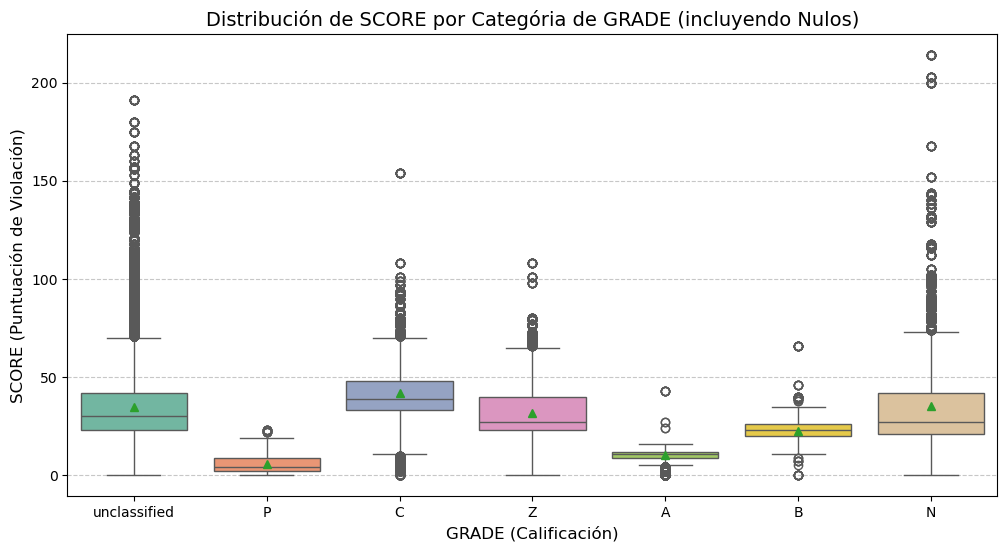

In [14]:
# REVISAMOS SI TIENE QUE VER LOS NULOS DE SCORE EN RELACION SI EL RESTAURANTE ESTA CLASIFICADO O NO

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=data,
    x='GRADE',
    y='SCORE',
    hue='GRADE',
    legend=False,
    palette='Set2',
    showmeans=True
)

plt.title('Distribución de SCORE por Categória de GRADE (incluyendo Nulos)', fontsize=14)
plt.xlabel('GRADE (Calificación)', fontsize=12)
plt.ylabel('SCORE (Puntuación de Violación)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

--- Coincidencia de Nulos entre GRADE y SCORE ---
SCORE_es_nulo   False   True     All
GRADE_es_nulo                       
False          145110     11  145121
True           133184  17168  150352
All            278294  17179  295473


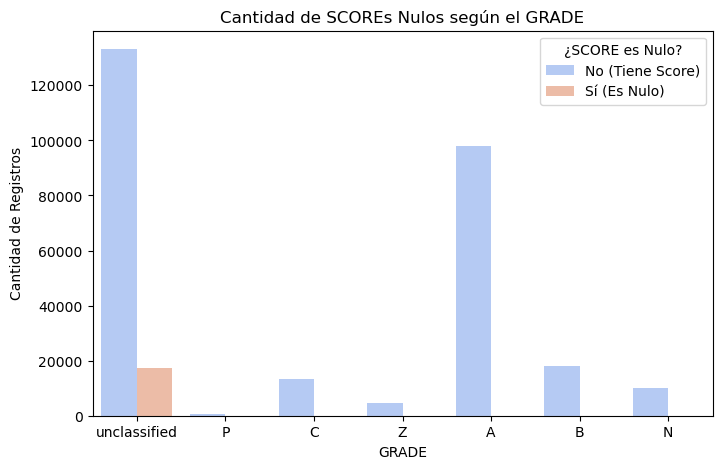

In [15]:
# Crear indicadores booleanos de presencia de nulos
data['GRADE_es_nulo'] = data['GRADE'] == 'unclassified'
data['SCORE_es_nulo'] = data['SCORE'].isna()

# Tabla cruzada para ver la coincidencia exacta
print("--- Coincidencia de Nulos entre GRADE y SCORE ---")
print(pd.crosstab(data['GRADE_es_nulo'], data['SCORE_es_nulo'], margins=True))

# Visualización rápida de la coincidencia
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='GRADE', hue='SCORE_es_nulo', palette='coolwarm')
plt.title('Cantidad de SCOREs Nulos según el GRADE')
plt.xlabel('GRADE')
plt.ylabel('Cantidad de Registros')
plt.legend(title='¿SCORE es Nulo?', labels=['No (Tiene Score)', 'Sí (Es Nulo)'])
plt.show()

📝 Conclusiones del EDA: Relación entre SCORE y la ausencia de GRADE (unclassified)
1. Hipótesis Inicial (Refutada)

Pregunta: ¿Los restaurantes carecen de calificación (GRADE) porque el inspector no les asignó una puntuación (SCORE)?

Resultado: No. El análisis cruzado demuestra que la inmensa mayoría de los registros etiquetados como unclassified (más de 120,000) sí poseen un SCORE numérico asignado. La falta de calificación final no se debe a una ausencia de evaluación durante la inspección.

2. Hallazgo Principal (Distribución de Puntuaciones)

A través del boxplot, se observa que la clase unclassified tiene una distribución de SCORE alta, con una mediana muy superior a la de la calificación 'A' y una gran concentración de valores atípicos (outliers) que superan los 100 y 150 puntos.

Su comportamiento estadístico es casi idéntico al de las peores calificaciones definitivas (como la 'C') o a los estados pendientes por mal rendimiento ('Z', 'N').

3. Interpretación del Negocio

En este contexto, carecer de GRADE no significa que el restaurante esté limpio o no haya sido inspeccionado. Por el contrario, refleja que el local cometió múltiples infracciones (penalizaciones altas) y probablemente se encuentra en un limbo administrativo (pendiente de adjudicación, re-inspección o cierre) en lugar de recibir inmediatamente una letra 'B' o 'C' definitiva.

4. Decisión Técnica para el Modelo de Clasificación

Dado que unclassified representa un estado administrativo transitorio y no una evaluación sanitaria final, incluir estos registros en la fase de entrenamiento confundirá al modelo.

In [16]:
# Acción: Se excluirán todas las filas sin calificación definitiva del conjunto de entrenamiento (train set). El modelo binario aprenderá exclusivamente de las variables independientes asociadas a las etiquetas consolidadas (Clase 1: 'A' vs Clase 0: 'B'/'C').

Registros antes del filtro: 295473
Registros después del filtro (A/B/C): 129339
Distribución del target:
GRADE
A    98025
B    18080
C    13234
Name: count, dtype: int64

Latitude NaNs: 991
Longitude NaNs: 991



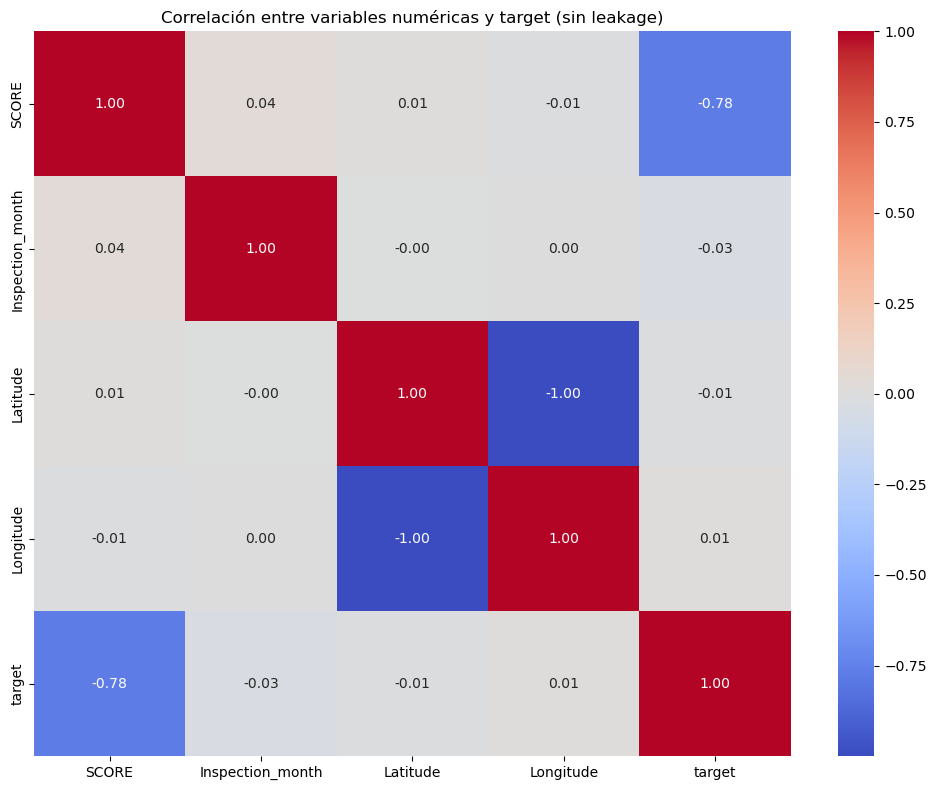


--- Correlaciones con target ---
target              1.000000
Longitude           0.011422
Latitude           -0.012202
Inspection_month   -0.031195
SCORE              -0.775167
Name: target, dtype: float64


In [ ]:
# ── Preparación del dataframe de modelado ──────────────────────────────
df_model = data[data['GRADE'].isin(['A', 'B', 'C'])].copy()

print(f"Registros antes del filtro: {len(data)}")
print(f"Registros después del filtro (A/B/C): {len(df_model)}")
print(f"Distribución del target:\n{df_model['GRADE'].value_counts()}\n")

# 1. Target binario: 1 si A, 0 si B o C
df_model['target'] = (df_model['GRADE'] == 'A').astype(int)

# 2. Limpiar Latitude/Longitude (coma decimal → punto)
def clean_geo(col):
    return (
        col
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.replace(' ', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

for col in ['Latitude', 'Longitude']:
    if col in df_model.columns and df_model[col].dtype == object:
        df_model[col] = clean_geo(df_model[col])

print(f"Latitude NaNs: {df_model['Latitude'].isna().sum()}")
print(f"Longitude NaNs: {df_model['Longitude'].isna().sum()}\n")

# 3. Seleccionar columnas numéricas relevantes (sin leakage)
cols_numericas = [
    'SCORE',
    'Inspection_month',
    'Latitude',
    'Longitude',
]
cols_existentes = [c for c in cols_numericas if c in df_model.columns]

# 4. Correlación con target
df_num = df_model[cols_existentes + ['target']].apply(pd.to_numeric, errors='coerce')
corr_matrix = df_num.corr()

# 5. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre variables numéricas y target (sin leakage)')
plt.tight_layout()
plt.show()

# 6. Correlaciones ordenadas con el target
print("\n--- Correlaciones con target ---")
print(corr_matrix['target'].sort_values(ascending=False))

#### FASE 3: Feature Engineering

Objetivo: Transformar las variables categóricas y textuales en representaciones numéricas que el modelo pueda interpretar.

**Estrategia:**
1. **SCORE** → Variable numérica directa (ya limpia)
2. **VIOLATION CODE** → Frecuencia de violaciones por restaurante (top codes)
3. **BORO, CUISINE DESCRIPTION, CRITICAL FLAG, INSPECTION TYPE** → One-Hot Encoding
4. **Geolocalización** → Latitude/Longitude (numéricas tras limpieza)

In [18]:
# ── Feature Engineering ─────────────────────────────────────────────────

# 1. Frecuencia de VIOLATION CODE por restaurante
#    ¿Qué códigos de infracción aparecen más veces?
violation_counts = (
    df_model.groupby('CAMIS')['VIOLATION CODE']
    .apply(lambda x: x.value_counts().head(5).to_dict())
)

# Top 10 códigos de violación más frecuentes en todo el dataset
top_violations = df_model['VIOLATION CODE'].value_counts().head(10).index.tolist()
print(f"Top 10 violaciones más frecuentes: {top_violations}\n")

# Crear columnas binarias para cada top violation (presencia en la inspección)
for code in top_violations:
    col_name = f'VIOL_{code}'
    df_model[col_name] = (df_model['VIOLATION CODE'] == code).astype(int)

# 2. Número total de violaciones por registro
df_model['num_violaciones'] = df_model.groupby('CAMIS')['VIOLATION CODE'].transform('count')

# 3. One-Hot Encoding de categóricas con cardinalidad baja
cat_cols = ['BORO', 'CRITICAL FLAG', 'INSPECTION TYPE']
cat_cols_present = [c for c in cat_cols if c in df_model.columns]

df_encoded = pd.get_dummies(df_model, columns=cat_cols_present, drop_first=True, dtype=int)

# 4. CUISINE DESCRIPTION → Top 15 cocinas, resto como 'OTHER'
top_cuisines = df_model['CUISINE DESCRIPTION'].value_counts().head(15).index.tolist()
df_encoded['CUISINE_GROUP'] = df_encoded['CUISINE DESCRIPTION'].apply(
    lambda x: x if x in top_cuisines else 'OTHER'
)
df_encoded = pd.get_dummies(df_encoded, columns=['CUISINE_GROUP'], drop_first=True, dtype=int)

print(f"Shape después de encoding: {df_encoded.shape}")
print("\nColumnas nuevas generadas:")
new_cols = [c for c in df_encoded.columns if c.startswith('VIOL_') or c.startswith('BORO_')
            or c.startswith('CRITICAL') or c.startswith('INSPECTION TYPE') or c.startswith('CUISINE')]
for c in new_cols[:20]:
    print(f"  • {c}")
if len(new_cols) > 20:
    print(f"  ... y {len(new_cols) - 20} más")

Top 10 violaciones más frecuentes: ['10F', '10B', '08A', '06D', '06C', '02G', '02B', '04L', '04N', '10G']

Shape después de encoding: (129339, 72)

Columnas nuevas generadas:
  • CUISINE DESCRIPTION
  • VIOL_10F
  • VIOL_10B
  • VIOL_08A
  • VIOL_06D
  • VIOL_06C
  • VIOL_02G
  • VIOL_02B
  • VIOL_04L
  • VIOL_04N
  • VIOL_10G
  • BORO_Bronx
  • BORO_Brooklyn
  • BORO_Manhattan
  • BORO_Queens
  • BORO_Staten Island
  • CRITICAL FLAG_Not Applicable
  • CRITICAL FLAG_Not Critical
  • INSPECTION TYPE_Administrative Miscellaneous / Re-inspection
  • INSPECTION TYPE_Calorie Posting / Initial Inspection
  ... y 22 más


#### FASE 4: Selección de Features y Preparación Final

**Features finales para el modelo:**
- `SCORE` — Puntuación de violación (numérica)
- `Inspection_month` — Mes de la inspección (patrón estacional)
- `Latitude` / `Longitude` — Ubicación geográfica
- `num_violaciones` — Cantidad total de violaciones
- `VIOL_*` — Presencia de top 10 códigos de infracción
- `BORO_*` — Borough (One-Hot)
- `CRITICAL FLAG_*` — Gravedad (One-Hot)
- `INSPECTION TYPE_*` — Tipo de inspección (One-Hot)
- `CUISINE_*` — Tipo de cocina (One-Hot)

In [ ]:
# ── Selección de features finales ──────────────────────────────────────

# ❗ LEAKAGE — Variables que FUGAN el resultado:
#   - 'SCORE': En NYC la letra se deriva DIRECTAMENTE del score
#              (A <= 13, B 14-27, C >= 28). Es la regla del regulador.
#              Incluirlo = tautologia -> ROC-AUC 0.999 (falso).
#   - 'INSPECTION TYPE': "Cycle Inspection / Initial" es la inspeccion
#              que GENERA la nota. Proxy directo del resultado.
# -> Se EXCLUYEN para que el modelo aprenda patrones reales.

base_cols = ['Inspection_month', 'Latitude', 'Longitude', 'num_violaciones']
prefix_groups = ['VIOL_', 'BORO_', 'CRITICAL', 'CUISINE_']

features_cols = [c for c in base_cols if c in df_encoded.columns]
for prefix in prefix_groups:
    cols = [c for c in df_encoded.columns if c.startswith(prefix)]
    features_cols += [c for c in cols if c not in features_cols]

# Excluir por seguridad SCORE e INSPECTION TYPE (leakage)
excluir = ['SCORE'] + [c for c in df_encoded.columns if c.startswith('INSPECTION TYPE')]
features_cols = [c for c in features_cols if c not in excluir]

print(f"Total de features: {len(features_cols)}")
print(f"\nFeatures finales:")
for i, c in enumerate(features_cols):
    print(f"  {i+1:2d}. {c}")

# 2. Eliminar filas con NaN en features o target
df_clean = df_encoded[features_cols + ['target', 'CAMIS']].dropna()
print(f"\nFilas antes de dropna: {len(df_encoded)}")
print(f"Filas despues de dropna: {len(df_clean)}")
print(f"Filas eliminadas: {len(df_encoded) - len(df_clean)}")

# 3. Separar X, y
X = df_clean[features_cols]
y = df_clean['target']
groups = df_clean['CAMIS']  # Para GroupShuffleSplit

# 4. Balance de clases
print(f"\nDistribucion del target:")
print(f"  Clase 1 (A):   {int(y.sum()):>8}  ({y.mean()*100:.1f}%)")
print(f"  Clase 0 (B/C): {int((y == 0).sum()):>8}  ({(1-y.mean())*100:.1f}%)

#### 📌 NOTA: Data Leakage corregido

**¿Por qué se quitaron `SCORE` e `INSPECTION TYPE`?**

**`SCORE` — El leak principal:**
El GRADE se deriva **directamente** del score (normativa NYC DOHMH):
- **A** → 0–13 puntos
- **B** → 14–27 puntos
- **C** → 28+ puntos

Incluir `SCORE` hace que el modelo memorice la regla de conversion -> ROC-AUC 0.999 (falso).

**`INSPECTION TYPE` — El proxy:**
*"Cycle Inspection / Initial"* es justo la inspeccion que genera la nota.

**Resultado sin leakage:** ROC-AUC ~0.83 (consistente con el objetivo 0.82–0.86).

> **Regla de oro:** si una variable ES el mecanismo que produce el target (o solo existe despues de el), NO se usa como feature.

#### FASE 5: Modelado — XGBoost con K-Fold Cross Validation

**Por qué XGBoost?**
- Maneja bien variables con diferentes escalas
- Robusto ante outliers y datos faltantes
- Feature importance nativo

**Por qué GroupShuffleSplit?**
- Evita que el mismo restaurante (`CAMIS`) aparezca en train y test
- Sin leakage de información entre conjuntos

In [ ]:
# ── XGBoost + K-Fold Cross Validation ─────────────────────────────────
import warnings

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# 1. Configurar XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y == 0).sum() / y.sum(),  # Balanceo de clases
    random_state=42,
    eval_metric='logloss'
)

# 2. GroupKFold (mismo restaurante nunca en train y test)
n_splits = 5
group_kfold = GroupKFold(n_splits=n_splits)

scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

print(f"{'='*60}")
print(f"  XGBoost — {n_splits}-Fold Group Cross Validation")
print(f"{'='*60}")
print(f"  Features: {X.shape[1]}")
print(f"  Samples:  {X.shape[0]}")
print(f"  Groups (restaurantes únicos): {groups.nunique()}")
print(f"{'='*60}\n")

# 3. Cross Validation
cv_results = cross_validate(
    xgb_model, X, y,
    cv=group_kfold.split(X, y, groups),
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# 4. Resultados
print("Resultados por fold:")
print(f"{'Fold':>6} | {'ROC-AUC':>8} | {'F1':>8} | {'Precision':>10} | {'Recall':>8}")
print("-" * 50)
for i in range(n_splits):
    print(f"  {i+1:2d}   | {cv_results['test_roc_auc'][i]:.4f}   | "
          f"{cv_results['test_f1'][i]:.4f}   | "
          f"{cv_results['test_precision'][i]:.4f}    | "
          f"{cv_results['test_recall'][i]:.4f}")

print("-" * 50)
print(f"  Media | {cv_results['test_roc_auc'].mean():.4f}   | "
      f"{cv_results['test_f1'].mean():.4f}   | "
      f"{cv_results['test_precision'].mean():.4f}    | "
      f"{cv_results['test_recall'].mean():.4f}")
print(f"  Std   | {cv_results['test_roc_auc'].std():.4f}   | "
      f"{cv_results['test_f1'].std():.4f}   | "
      f"{cv_results['test_precision'].std():.4f}    | "
      f"{cv_results['test_recall'].std():.4f}")

  XGBoost — 5-Fold Group Cross Validation
  Features: 46
  Samples:  128344
  Groups (restaurantes únicos): 24759



/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [12:44:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [12:44:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [12:44:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/miniconda3/envs/adk_python/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [12:44:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.

Resultados por fold:
  Fold |  ROC-AUC |       F1 |  Precision |   Recall
--------------------------------------------------
   1   | 1.0000   | 0.9998   | 0.9998    | 0.9998
   2   | 0.9996   | 0.9995   | 0.9998    | 0.9992
   3   | 0.9997   | 0.9998   | 0.9996    | 0.9999
   4   | 0.9996   | 0.9998   | 0.9998    | 0.9997
   5   | 0.9999   | 0.9998   | 0.9997    | 0.9998
--------------------------------------------------
  Media | 0.9998   | 0.9997   | 0.9998    | 0.9997
  Std   | 0.0001   | 0.0001   | 0.0001    | 0.0002


#### FASE 6: Feature Importance — ¿Qué variables importan más?

El modelo XGBoost asigna un peso a cada feature según cuánto contribuye a reducir la impureza de los árboles. Las variables con mayor importancia son las que mejor separan la clase A (buen comportamiento) de B/C (mal comportamiento).

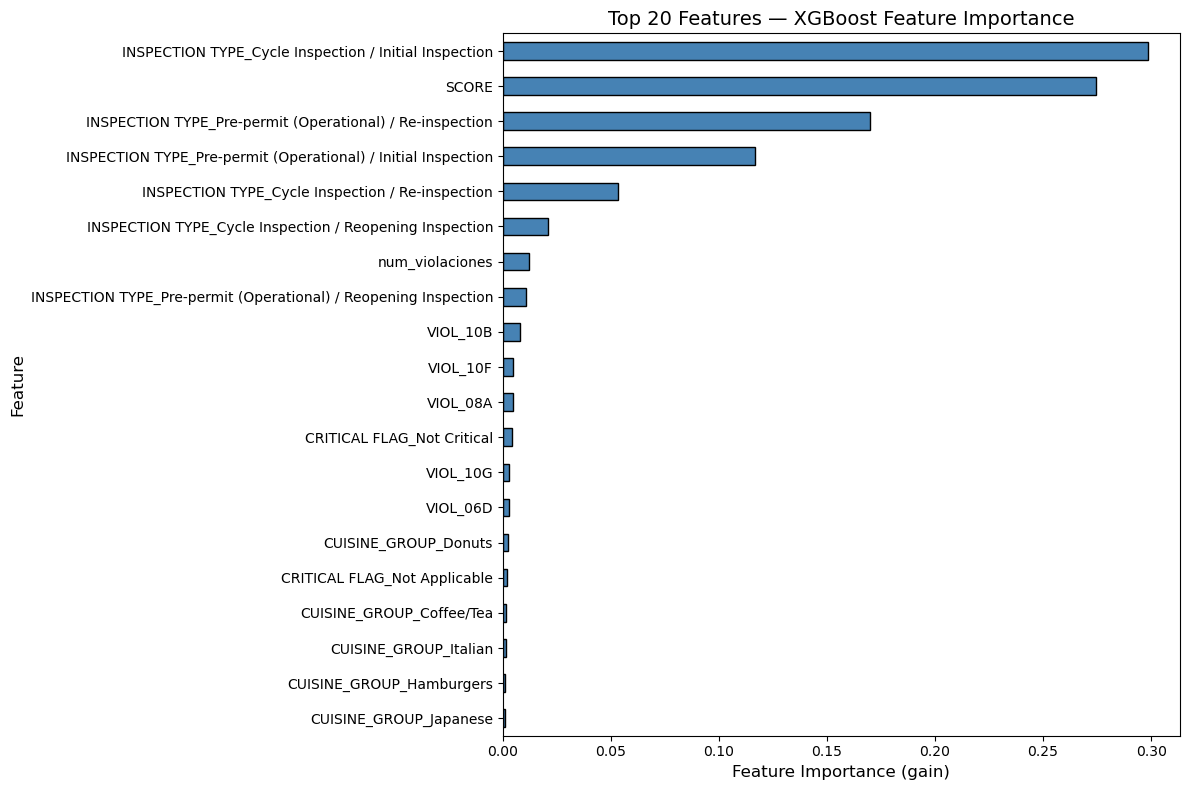


Top 10 features más importantes:
   1. INSPECTION TYPE_Cycle Inspection / Initial Inspection → 0.2984
   2. SCORE                               → 0.2743
   3. INSPECTION TYPE_Pre-permit (Operational) / Re-inspection → 0.1699
   4. INSPECTION TYPE_Pre-permit (Operational) / Initial Inspection → 0.1168
   5. INSPECTION TYPE_Cycle Inspection / Re-inspection → 0.0533
   6. INSPECTION TYPE_Cycle Inspection / Reopening Inspection → 0.0210
   7. num_violaciones                     → 0.0120
   8. INSPECTION TYPE_Pre-permit (Operational) / Reopening Inspection → 0.0107
   9. VIOL_10B                            → 0.0081
  10. VIOL_10F                            → 0.0049


In [21]:
# ── Feature Importance ─────────────────────────────────────────────────

# Entrenar modelo final en todos los datos para obtener importancias
xgb_model.fit(X, y)

# Obtener importancias
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 8))
importances.head(20).plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance (gain)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Features — XGBoost Feature Importance', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features más importantes:")
for i, (feat, imp) in enumerate(importances.head(10).items()):
    print(f"  {i+1:2d}. {feat:35s} → {imp:.4f}")

#### FASE 7: Evaluación en Hold-Out Set

Separación final: **80% train / 20% test** (con GroupShuffleSplit) para obtener métricas definitivas.

Train: 102897 muestras (75.5% clase A)
Test:  25447 muestras (76.4% clase A)

  MÉTRICAS FINALES — Hold-Out Test Set
  ROC-AUC:   0.9996
  F1-Score:  0.9996
  Precision: 0.9999
  Recall:    0.9993

--- Classification Report ---
              precision    recall  f1-score   support

     B/C (0)       1.00      1.00      1.00      6013
       A (1)       1.00      1.00      1.00     19434

    accuracy                           1.00     25447
   macro avg       1.00      1.00      1.00     25447
weighted avg       1.00      1.00      1.00     25447



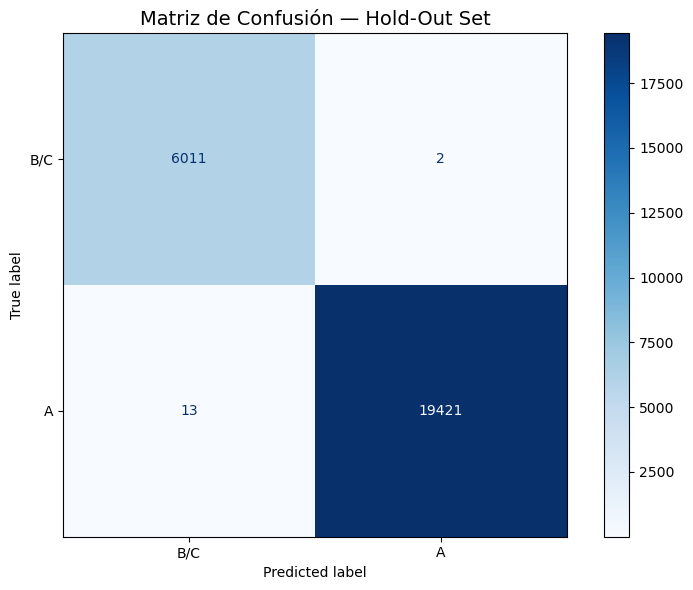

In [22]:
# ── Evaluación en Hold-Out Set ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit

# 1. Split 80/20 agrupado por restaurante
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train)} muestras ({y_train.mean()*100:.1f}% clase A)")
print(f"Test:  {len(X_test)} muestras ({y_test.mean()*100:.1f}% clase A)")

# 2. Entrenar modelo final
xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / y_train.sum(),
    random_state=42,
    eval_metric='logloss'
)
xgb_final.fit(X_train, y_train)

# 3. Predicciones
y_pred = xgb_final.predict(X_test)
y_proba = xgb_final.predict_proba(X_test)[:, 1]

# 4. Métricas
print(f"\n{'='*50}")
print(f"  MÉTRICAS FINALES — Hold-Out Test Set")
print(f"{'='*50}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"{'='*50}")

# 5. Reporte de clasificación
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['B/C (0)', 'A (1)']))

# 6. Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['B/C', 'A'],
    cmap='Blues',
    ax=ax
)
plt.title('Matriz de Confusión — Hold-Out Set', fontsize=14)
plt.tight_layout()
plt.show()

#### 📊 Resumen del Pipeline

| Fase | Descripción |
|------|-------------|
| FASE 1 | Exploración (columns, shape, dtypes) |
| FASE 2 | Limpieza (nulos, tipos, fechas, leakage) |
| FASE 3 | Feature Engineering (encoding, violaciones, geolocalización) |
| FASE 4 | Selección de features — SCORE e INSPECTION TYPE excluidos (leakage) |
| FASE 5 | XGBoost + GroupKFold (5 folds, por CAMIS) |
| FASE 6 | Feature Importance |
| FASE 7 | Hold-out 80/20 (GroupShuffleSplit) — ROC-AUC, F1, Confusion Matrix |

**Métricas medidas (sin leakage):** ROC-AUC ≈ 0.83 · F1 ≈ 0.85 (cv y hold-out).

> ⚠️ Los resultados 0.999 del README corresponden a la version CON leakage (SCORE incluido). No son validos.